# SysSim — ARIA Tutorial (2026-05-22)

SysSim (https://github.com/AISysSim/SysSim) estimates the step time and peak memory of LLM training on hardware
you don't have, without running real computation. This notebook walks through six sections:

0. **Getting Started** — install → (profile) → calibrate → your first simulation (inspect the `SimulationReport`)
1. **SysSim vs. real GH200** — Qwen3-8B & Llama-3-8B, single- and multi-node, checked within 10%
2. **Sweeping** — Batch / Seqlen / TP / Precision sweeps
3. **New accelerator** — AMD MI300X (mock)
4. **Accelerator integration** — custom estimator via `HardwareConfig(estimator=...)`

**Before you run anything:** _Runtime → Change runtime type → T4 GPU_.
(If the install cell fails on T4, fall back to L4 or A100.)

In [1]:
import torch
assert torch.cuda.is_available(), (
    "SysSim requires a GPU runtime. "
    "Runtime → Change runtime type → T4 GPU (or L4/A100), then re-run."
)
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA GH200 120GB


## §0. Getting Started

The recommended path for a first run of SysSim: **install → (profile) → calibrate → simulate**. By the end you'll have the GH200-calibrated cost model set up and will have run your first simulation, inspecting the full `SimulationReport`.

### Step 1 — Installation

Clone SysSim (with submodules) and install it into the Colab runtime. This is the only step here that performs a heavy install; it takes ~3–5 minutes on a fresh runtime.

In [ ]:
import os, subprocess
import logging, warnings
import shutil # Import shutil for directory removal

# Silence benign Megatron / Apex / RNG warnings so the demo output stays readable.
logging.getLogger("megatron.core.tensor_parallel.random").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="CPU RNG state changed within GPU RNG context")
warnings.filterwarnings("ignore", message="Module is None. Skipping .* hook.")
warnings.filterwarnings("ignore", message="Apex is not installed.*")
warnings.filterwarnings("ignore", message="full scope is deprecated.*")

# 1) Clone SysSim (mksit/aria_tutorial branch, with submodules) into the Colab runtime.
#    Ensure a clean state by removing the directory if it exists.
if os.path.exists("SysSim"):
    print("SysSim directory already exists. Attempting to remove with rm -rf to ensure clean clone.")
    subprocess.run("rm -rf SysSim", shell=True, check=True)

# Clone the repository. Git will create the 'SysSim' directory.
print("Cloning SysSim (mksit/aria_tutorial branch)...")
subprocess.run(
    "git clone --branch mksit/aria_tutorial https://github.com/AISysSim/SysSim.git",
    shell=True, check=True,
)

# Change into the SysSim directory for submodule updates
if os.path.basename(os.getcwd()) != "SysSim":
    %cd SysSim

# Configure git to use https for git:// protocol, which can help with submodule cloning issues
print("Configuring git to use HTTPS for git:// and SSH (git@) URLs (the PLENA submodule uses SSH)...")
subprocess.run(
    "git config --global url.\"https://\".insteadOf git://",
    shell=True, check=True
)
subprocess.run(
    "git config --global url.\"https://github.com/\".insteadOf \"git@github.com:\"",
    shell=True, check=True
)

print("Initializing and updating submodules...")
subprocess.run(
    "git submodule update --init --recursive",
    shell=True # Removed check=True to allow script to continue on non-fatal errors
)

# 2) Make the editable install work on Colab.
#    The repo root holds several top-level dirs (data/, syssim/, third_party/),
#    so setuptools' flat-layout auto-discovery refuses to guess. Scope it to the
#    syssim package explicitly. (Runtime-only tweak; the repo is unchanged upstream.)
_pp = "pyproject.toml"
_txt = open(_pp).read()
if "tool.setuptools.packages.find" not in _txt:
    with open(_pp, "a") as _f:
        _f.write('\n[tool.setuptools.packages.find]\ninclude = ["syssim*"]\n')

# 3) Install the two SysSim deps that aren't already on a Colab runtime.
#    Everything else SysSim needs (numpy, pandas, pyarrow, pyyaml, scikit-learn,
#    torch, transformers) ships with Colab. We also skip megatron-bridge and
#    flashinfer-python: they don't build on a T4 and aren't used by this demo.
!pip install -q lightgbm megatron-core 2>&1 | tail -3

# 4) Install SysSim itself (editable, no dep re-resolution).
!pip install -q --no-deps -e . 2>&1 | tail -3

import syssim
print(f"SysSim {syssim.__version__ if hasattr(syssim,'__version__') else ''} imported from: {syssim.__file__}")

  DEPRECATION: Setting PIP_CONSTRAINT will not affect build constraints in the future, pip 26.2 will enforce this behaviour change. A possible replacement is to specify build constraints using --build-constraint or PIP_BUILD_CONSTRAINT. To disable this warning without any build constraints set --use-feature=build-constraint or PIP_USE_FEATURE="build-constraint".


SysSim  imported from: /lus/lfs1aip2/projects/u6kg/mksit/SysSim/syssim/__init__.py


### Step 2 — Profiling (shown, not run here)

Profiling measures the **real GPU self-time** of every operator a Megatron transformer layer dispatches, across SysSim's architecture/shape space, and writes them to `data/<device>/profile.parquet`. These measurements are what calibrates the per-operator cost model.

Profiling needs the **actual target GPUs** (real kernels on the real device), so it is **not run in this notebook** — Colab's T4 is not a GH200. The real command on a 4-GPU GH200 node is:

```bash
python -m syssim profile --out data/gh200 --num-workers 4
```

In [3]:
# DRY RUN ONLY — previews the profiling job list (layer configs x tensor-parallel
# shapes). It does NOT profile and does NOT touch the GPU. Real profiling needs the
# target GH200 GPUs; we ship data/gh200/profile.parquet so you can skip it.
!python -m syssim profile --out data/gh200 --dry-run

dry run: 158 layer-config jobs (42 configs x tensor-parallel [1, 2, 4, 8], divisible only); seq points [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


### Step 3 — Calibration

Calibration fits the per-operator cost model from the shipped profile. For each operator family (GEMM, elementwise, reduction) it learns a small LightGBM **residual** — `log(measured_time / roofline_anchor)` as a function of op size — on top of the roofline floor. This is **CPU-only**, so it runs fine here on Colab.

It reads `data/gh200/profile.parquet` and writes the per-family models (`gemm_model.lgb`, `elementwise_model.lgb`, `reduction_model.lgb`) plus `manifest.json` into `data/gh200/`.

In [4]:
# Fit the per-family residual trees from the shipped GH200 profile (CPU-only).
# Writes gemm/elementwise/reduction *.lgb + manifest.json into data/gh200/.
!python -m syssim calibrate --data data/gh200 --hardware examples/configs/hardware/isambard_gh200_4gpu.yaml

calibrate: loaded 23016 (op, shape) rows from data/gh200/profile.parquet


calibrate: built feature codes (22 op subtypes); families = gemm, elementwise, reduction
calibrate: fitting gemm ...


calibrate: gemm done -> median_ape=6.2%  p95=64.3%  (train=4573 val=1265)
calibrate: fitting elementwise ...


calibrate: elementwise done -> median_ape=6.0%  p95=44.6%  (train=10856 val=2045)
calibrate: fitting reduction ...


calibrate: reduction done -> median_ape=4.6%  p95=19.3%  (train=3831 val=446)
calibrated 3 families -> data/gh200 (gemm_model.lgb, elementwise_model.lgb, reduction_model.lgb + manifest.json)


### Step 4 — Your first simulation

Run one config end-to-end and inspect the `SimulationReport` SysSim returns: step time with the
forward / backward / optimizer breakdown, exposed collective time, achieved TFLOP/s, MFU / HFU, and
peak memory. (Qwen3-8B, TP=2, on the GH200-calibrated model from Step 3.)

In [ ]:
import syssim

report = syssim.simulate(
    model="examples/configs/models/qwen3-8b.yaml",
    hardware="examples/configs/hardware/isambard_gh200_4gpu.yaml",
    parallelism=syssim.ParallelismConfig(tp=2, dp=1),
    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16", recompute="full"),
)
print(report)

SimulationReport(
  step_time_ms        = 633.5223
    forward_ms        = 180.0801
    backward_ms       = 376.4860
    optimizer_ms      = 39.4327
  collective_total_ms = 53.9978
  collective_exposed  = 37.5235
  achieved_tflops     = 187.80
  mfu                 = 9.49%
  hfu                 = 12.65%
  peak_memory_gb      = 66.456
  Bottlenecks(
    dominant_op_type = math
    top_ops_by_time  = [('optimizer_step_4510', 39.43271286447761), ('op_1220_aten.mm', 4.286653309549106), ('op_1221_aten.mm', 4.21173467212024)]
    peak_module      = DistributedDataParallel
  )
)


## §1. SysSim vs. real GH200 (Qwen3-8B & Llama-3-8B)

Now check SysSim against **real Megatron-core measurements** on GH200. The measured numbers come from `docs/megatron_gh200_validation/` (the published reference runs), and the hardware YAMLs carry `calibrated_model: data/gh200` so `simulate(...)` uses the GH200-calibrated cost model from §0.

Across the full validation suite — 16 single-node + 8 multi-node (2- and 4-node) cases — SysSim lands **within 10% on 24/24** (mean step-time error ~4%). The two sub-sections below show the **single-node** and **multi-node** slices.

#### Single-node — one 4-GPU GH200

`tp2` (TP=2) and `dp4` (DP=4) on a single node, bf16, full recompute. `dp4` uses Megatron's distributed optimizer (ZeRO-1) to shard optimizer state across the 4 data-parallel ranks.

     model case  sim_ms  real_ms  step_err_%  sim_gb  real_gb  mem_err_%
  Qwen3-8B  tp2   633.5    694.8         8.8    66.5     64.6        2.8
  Qwen3-8B  dp4  1160.9   1157.3         0.3    69.1     65.8        5.0
Llama-3-8B  tp2  1776.7   1842.4         3.6    69.5     69.4        0.1
Llama-3-8B  dp4  3243.4   3360.2         3.5    79.9     79.9        0.0

Max step-time error: 8.8%  |  Max memory error: 5.0%  (target: within 10%)


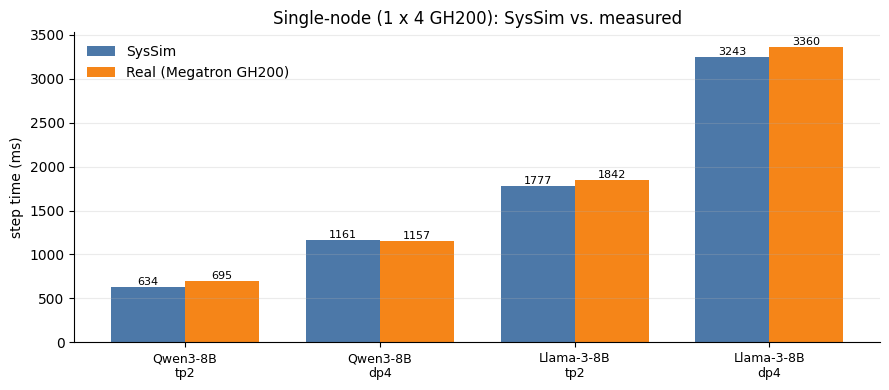

In [ ]:
import syssim
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

HW_1NODE = "examples/configs/hardware/isambard_gh200_4gpu.yaml"   # 1 node, 4 GPUs (calibrated_model: data/gh200)
HW_4NODE = "examples/configs/hardware/isambard_gh200_4node.yaml"  # 4 nodes, 16 GPUs (+ inter-node Slingshot)
MODELS = {
    "Qwen3-8B": "examples/configs/models/qwen3-8b.yaml",
    "Llama-3-8B": "examples/megatron/llama3-8b.yaml",
}

def headline_compare(cases, title):
    """Run each case through SysSim, tabulate vs. measured GH200, and bar-chart step time."""
    rows = []
    for model_name in MODELS:
        for case, cfg in cases[model_name].items():
            r = syssim.simulate(
                model=MODELS[model_name], hardware=cfg["hw"],
                parallelism=syssim.ParallelismConfig(tp=cfg["tp"], dp=cfg["dp"]),
                training=syssim.TrainingConfig(
                    micro_batch=cfg["micro_batch"], global_batch=cfg["global_batch"],
                    dtype="bf16", recompute="full",
                    use_distributed_optimizer=cfg["distopt"]),
            )
            rows.append({
                "model": model_name, "case": case,
                "sim_ms": round(r.step_time_ms, 1), "real_ms": cfg["real_ms"],
                "step_err_%": round(100 * abs(r.step_time_ms - cfg["real_ms"]) / cfg["real_ms"], 1),
                "sim_gb": round(r.peak_memory_gb, 1), "real_gb": round(cfg["real_gb"], 1),
                "mem_err_%": round(100 * abs(r.peak_memory_gb - cfg["real_gb"]) / cfg["real_gb"], 1),
            })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print(f"\nMax step-time error: {df['step_err_%'].max():.1f}%  |  "
          f"Max memory error: {df['mem_err_%'].max():.1f}%  (target: within 10%)")

    labels = [f"{m}\n{c}" for m, c in zip(df["model"], df["case"])]
    x = range(len(df)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar([i - w/2 for i in x], df["sim_ms"], width=w, label="SysSim", color="#4C78A8")
    ax.bar([i + w/2 for i in x], df["real_ms"], width=w, label="Real (Megatron GH200)", color="#F58518")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("step time (ms)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
    for i, (s, rl) in enumerate(zip(df["sim_ms"], df["real_ms"])):
        ax.text(i - w/2, s, f"{s:.0f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w/2, rl, f"{rl:.0f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()
    return df

# Single-node: one 4-GPU GH200.
SINGLE_NODE = {
    "Qwen3-8B": {
        "tp2": dict(hw=HW_1NODE, tp=2, dp=1, micro_batch=1, global_batch=1, distopt=False, real_ms=694.8,  real_gb=64.63),
        "dp4": dict(hw=HW_1NODE, tp=1, dp=4, micro_batch=1, global_batch=4, distopt=True,  real_ms=1157.3, real_gb=65.84),
    },
    "Llama-3-8B": {
        "tp2": dict(hw=HW_1NODE, tp=2, dp=1, micro_batch=1, global_batch=1, distopt=False, real_ms=1842.4, real_gb=69.41),
        "dp4": dict(hw=HW_1NODE, tp=1, dp=4, micro_batch=1, global_batch=4, distopt=True,  real_ms=3360.2, real_gb=79.93),
    },
}
cmp_single = headline_compare(SINGLE_NODE, "Single-node (1 x 4 GH200): SysSim vs. measured")

#### Multi-node — 4 nodes × 4 GPUs (16 GPUs)

`tp4dp4` (TP=4 × DP=4) fanned across 4 GH200 nodes. SysSim simulates the inter-node Slingshot fabric, so this runs on the **same single Colab GPU** — no real multi-node job is required. (Reuses `headline_compare` from the single-node cell.)

     model         case  sim_ms  real_ms  step_err_%  sim_gb  real_gb  mem_err_%
  Qwen3-8B 4node tp4dp4   483.9    472.1         2.5    19.7     18.7        5.4
Llama-3-8B 4node tp4dp4  1117.4   1053.6         6.1    22.4     22.1        1.2

Max step-time error: 6.1%  |  Max memory error: 5.4%  (target: within 10%)


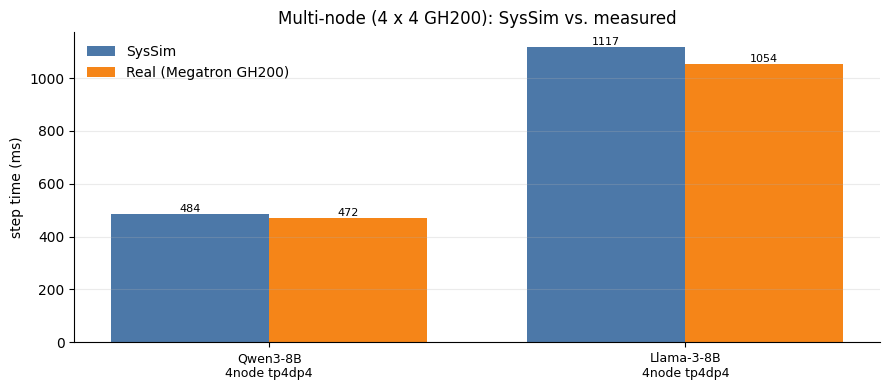

In [ ]:
# Multi-node: 4 nodes x 4 GPUs = 16 GPUs (TP=4 x DP=4). SysSim models the inter-node
# Slingshot fabric, so this still runs on the single Colab GPU -- no real cluster needed.
MULTI_NODE = {
    "Qwen3-8B": {
        "4node tp4dp4": dict(hw=HW_4NODE, tp=4, dp=4, micro_batch=1, global_batch=4, distopt=True, real_ms=472.1,  real_gb=18.69),
    },
    "Llama-3-8B": {
        "4node tp4dp4": dict(hw=HW_4NODE, tp=4, dp=4, micro_batch=1, global_batch=4, distopt=True, real_ms=1053.6, real_gb=22.15),
    },
}
cmp_multi = headline_compare(MULTI_NODE, "Multi-node (4 x 4 GH200): SysSim vs. measured")

## §2. Sweeping — Batch / Seqlen / TP / Precision

With the cost model calibrated, explore the configuration space *without touching a GPU* — change one
knob and read off the predicted effect. SysSim's `sweep(...)` helper re-runs `simulate()` across a
config axis and returns a tidy table (`.to_dataframe()`, plus `.best(metric)`).

Model = **Qwen3-1.7B**, hardware = **GH200 (one node, 4 GPUs)**. We sweep one knob at a time —
micro-batch, sequence length, tensor-parallel (TP) size and precision (bf16/fp8) — each with its own table and trend plot.
The dashed line in the memory panel marks the 96 GB per-GPU limit, so you can see where a config
would OOM.

In [ ]:
import syssim
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

QWEN3 = "examples/configs/models/qwen3-1_7b.yaml"              # small model -> fast sweeps
HW    = "examples/configs/hardware/isambard_gh200_4gpu.yaml"   # GH200, one node (4 GPUs)
GPU_MEM_GB = 96                                                # per-GPU HBM (OOM line)

def plot_sweep(sw, axis, title):
    """Print a Sweep as a table and plot step time / memory / MFU vs the swept axis."""
    df = sw.to_dataframe() if hasattr(sw, "to_dataframe") else sw
    print(df.to_string(index=False))
    x = [str(v) for v in df[axis]]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, (metric, lbl) in zip(axes, [("step_time_ms", "step time (ms)"),
                                        ("peak_memory_gb", "peak memory (GB)"),
                                        ("mfu", "MFU")]):
        ax.plot(x, df[metric], marker="o", linewidth=2, color="#4C78A8")
        ax.set_xlabel(axis.split(".")[-1]); ax.set_title(lbl); ax.grid(alpha=0.25)
        if metric == "peak_memory_gb":
            ax.axhline(GPU_MEM_GB, color="#E45756", ls="--", lw=1, label=f"{GPU_MEM_GB} GB")
            ax.legend(fontsize=7, frameon=False)
    fig.suptitle(title, y=1.03); fig.tight_layout(); plt.show()

#### Micro-batch size

Bigger micro-batches pack more tokens per step (higher MFU) but cost more activation memory. Sweep
`training.micro_batch` ∈ {1, 2, 4, 8, 16} at TP=2, DP=2 — the large values blow past the 96 GB limit,
which SysSim flags as OOM *before* you ever launch.

 training.micro_batch  step_time_ms      mfu  peak_memory_gb
                    1   2410.145664 0.047561       44.347936
                    2   2342.855917 0.048927       71.882301
                    4   2322.783908 0.049350      126.951030
                    8   2260.839439 0.050702      237.088489
                   16   2213.665817 0.051783      457.363406


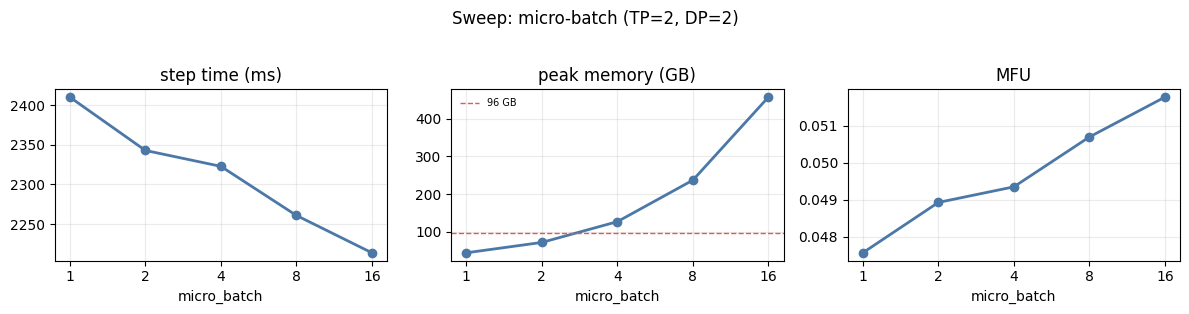

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(tp=2, dp=2),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=32, dtype="bf16"),
        over={"training.micro_batch": [1, 2, 4, 8, 16]}),
    "training.micro_batch", "Sweep: micro-batch (TP=2, DP=2)")

#### Sequence length

Attention cost grows ~quadratically in sequence length, so step time and activation memory both climb.
`seq_length` lives in the model YAML, so we sweep the `model.seq_length` axis ∈ {2048, 4096, 8192} at
TP=2, DP=2.

 model.seq_length  step_time_ms      mfu  peak_memory_gb
             2048    240.559591 0.053501       25.803425
             4096    617.697142 0.046394       44.347936
             8192   1945.791973 0.035452      110.050500


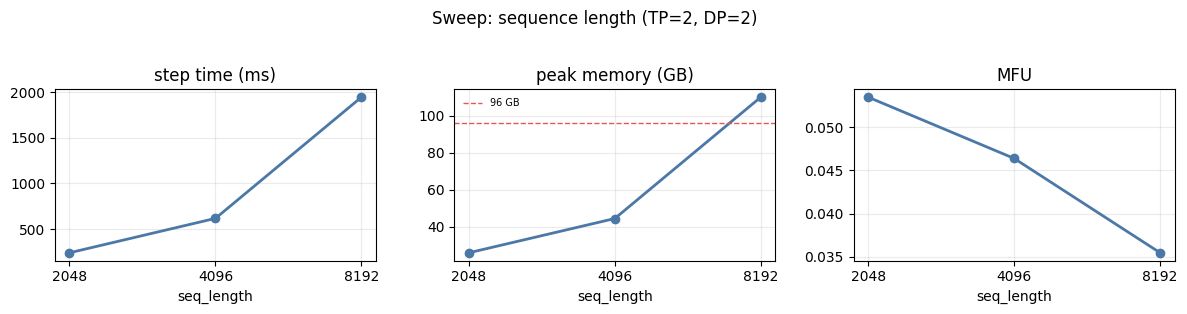

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(tp=2, dp=2),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="bf16"),
        over={"model.seq_length": [2048, 4096, 8192]}),
    "model.seq_length", "Sweep: sequence length (TP=2, DP=2)")

#### Tensor-parallel (TP) size

TP shards each layer's weights and activations across GPUs: less memory per GPU, more all-reduce traffic
on the critical path. Sweep `parallelism.tp` ∈ {1, 2, 4} at DP=1 (Qwen3-1.7B has 8 KV groups, so TP
beyond that buys little — we keep it ≤4).

 parallelism.tp  step_time_ms      mfu  peak_memory_gb
              1    275.910657 0.103865       84.604723
              2    156.015349 0.091841       44.347936
              4    103.290790 0.069361       24.219541


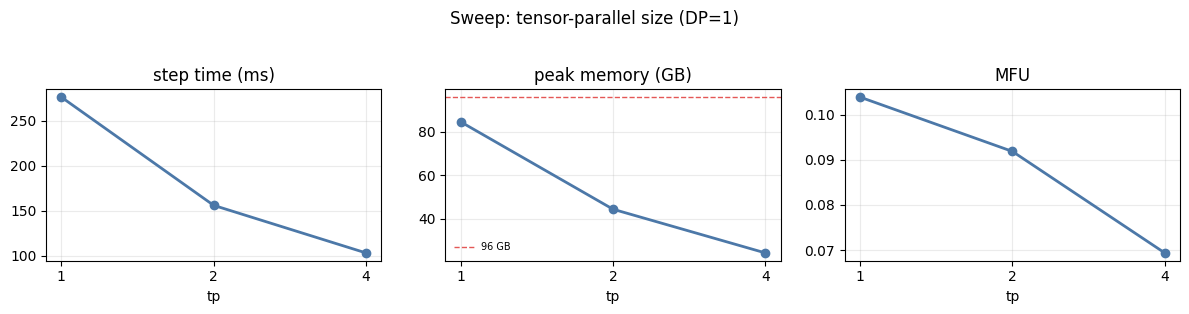

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(dp=1),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"),
        over={"parallelism.tp": [1, 2, 4]}),
    "parallelism.tp", "Sweep: tensor-parallel size (DP=1)")

#### Precision (bf16 vs fp8)

Lower precision raises the matrix-engine peak (GH200: bf16 1979 → fp8 3958 TFLOP/s). Sweep
`training.dtype` ∈ {bf16, fp8} at TP=2, DP=2.

> **fp8 figures are illustrative.** fp8's payoff is shape- and kernel-dependent — cast/scale overhead
> and small GEMMs can erase the peak advantage, and fp8 training carries extra buffers (more memory).
> For a model this small fp8 is *not* a clear win here; read the exact fp8 numbers with care.

training.dtype  step_time_ms      mfu  peak_memory_gb
          bf16    617.697142 0.046394       44.347936
           fp8   1018.677298 0.028132       62.230360


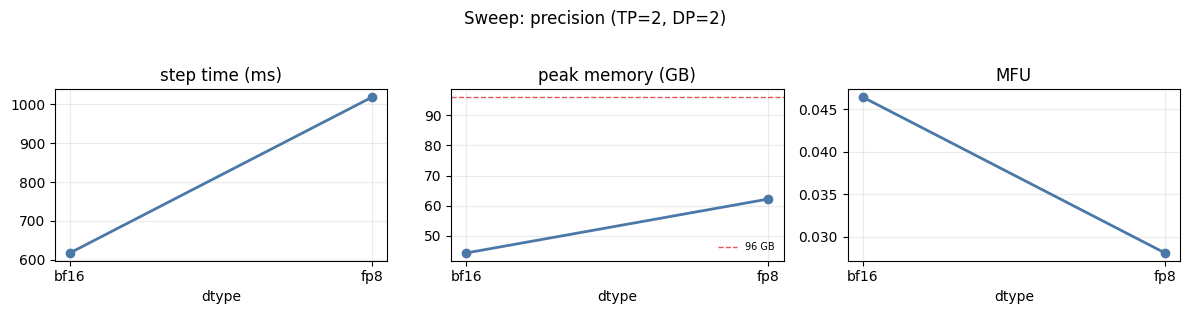

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(tp=2, dp=2),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="bf16"),
        over={"training.dtype": ["bf16", "fp8"]}),
    "training.dtype", "Sweep: precision (TP=2, DP=2)")

## §3. New accelerator — AMD MI300X (mock)

SysSim isn't GH200-specific: any accelerator plugs in through a hardware YAML and the same
**profile → calibrate → simulate** flow from §1. Here we bring up **AMD MI300X**.

We don't have MI300X hardware or profiling data, so this is a **mock**: a hand-written
`examples/configs/hardware/mi300x_mock.yaml` with AMD spec-sheet peaks and **no calibrated cost
model**, so SysSim uses its roofline floor. The numbers below are *illustrative* — the point is the
workflow for adding a new device.

#### 1. Profile (on real MI300X — not run here)

Profiling measures real per-operator times on the target device and writes
`data/<device>/profile.parquet`. It needs the actual MI300X GPUs, so it is shown, not run:

```bash
python -m syssim profile --out data/mi300x --num-workers 8
```

#### 2. Calibrate (needs the profile — placeholder)

Calibration fits the per-operator residual model from `data/mi300x/profile.parquet`:

```bash
python -m syssim calibrate --data data/mi300x --hardware examples/configs/hardware/mi300x_mock.yaml
```

Without real MI300X data we skip this: `mi300x_mock.yaml` has no `calibrated_model:` key, so
`simulate(...)` falls back to the roofline floor (an optimistic upper bound, no learned efficiency).

#### 3. Simulate one case and compare to a real run

With the hardware YAML in hand, `simulate()` runs exactly as before — no MI300X GPU required. We
simulate a single config (Qwen3-1.7B, one GPU) and line it up against a measured run. We have no
MI300X here, so the `real_*` values are **placeholders** — drop in a real measurement once you have
the device.

In [ ]:
MI300X = "examples/configs/hardware/mi300x_mock.yaml"
r = syssim.simulate(model=QWEN3, hardware=MI300X,
                    parallelism=syssim.ParallelismConfig(tp=1, dp=1),
                    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"))

# PLACEHOLDER measured numbers — replace with a real MI300X run.
real_ms, real_gb = 300.0, 85.0
pd.DataFrame([{
    "case": "Qwen3-1.7B - 1xMI300X - tp1",
    "sim_ms": round(r.step_time_ms, 1), "real_ms (placeholder)": real_ms,
    "sim_gb": round(r.peak_memory_gb, 1), "real_gb (placeholder)": real_gb,
}])

,case,sim_ms,real_ms (placeholder),sim_gb,real_gb (placeholder)
0,Qwen3-1.7B - 1xMI300X - tp1,131.4,300.0,84.6,85.0


## §4. Accelerator integration — custom estimator (PLENA)

SysSim routes every operator's timing through the `Estimator` protocol (`estimate_op(...) -> ms`). A
new accelerator plugs in by attaching such an estimator to `HardwareConfig(estimator=...)`; the tracer
and the training simulator are unchanged.

Here the estimator is **PLENA**, an analytic accelerator performance model wrapped by
`syssim.external.plena`. It reads the `third_party/PLENA_Simulator` submodule that the §0 install cell
cloned, so each traced op is timed by PLENA's model instead of the GPU roofline.

In [ ]:
import syssim
from syssim.external.plena import PLENAConfig, PLENAEstimator
from syssim.training.spec import HardwareConfig

# PLENA's analytic accelerator model, plugged in as the per-op estimator.
plena_estimator = PLENAEstimator(PLENAConfig.from_plena_submodule(frequency_hz=1.0e9))

accel_hw = HardwareConfig(
    peak_tflops_mm=1979, peak_tflops_math=989, peak_memory_bandwidth_GBps=3350,
    gpus_per_node=1, gpu_memory_GB=128,
    topology={"dims": ["fully_connected"], "size": [1], "bandwidth": [400], "latency": [12000]},
    estimator=plena_estimator, # Plug in the PLENA estimator here!!
)

report = syssim.simulate(
    model="examples/configs/models/qwen3-1_7b.yaml", hardware=accel_hw,
    parallelism=syssim.ParallelismConfig(tp=1, dp=1),
    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"),
)
print("estimator =", type(accel_hw.estimator).__name__)
print(report)

estimator = PLENAEstimator
SimulationReport(
  step_time_ms        = 223.7656
    forward_ms        = 59.2732
    backward_ms       = 150.1114
    optimizer_ms      = 14.3809
  collective_total_ms = 0.0000
  collective_exposed  = 0.0000
  achieved_tflops     = 253.45
  mfu                 = 12.81%
  hfu                 = 12.81%
  peak_memory_gb      = 84.605
  Bottlenecks(
    dominant_op_type = gemm
    top_ops_by_time  = [('optimizer_step_2217', 14.380865260895522), ('op_921_aten.mm', 4.9152), ('op_908_aten.mm', 4.8619520000000005)]
    peak_module      = DistributedDataParallel
  )
)


The key integration point is the `estimator` field on `HardwareConfig`. The simulator needs no
separate code path for the accelerator: traced operators call the configured estimator, and the
stream-queue runtime consumes the resulting per-op timings.